<a href="https://colab.research.google.com/github/knaeeim/50projects50days/blob/master/BrainTumorMRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import userdata

# 1. Load your single Kaggle API token from Secrets
os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')

# 2. Download and unzip the brain tumor MRI dataset
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:02<00:00, 59.9MB/s]



In [ ]:
import os
import glob
import pandas as pd
from sklearn.model_selection import StratifiedKFold

data_dir = '/content/'
folders_to_scan = ['Training', 'Testing']
classes = ['glioma', 'meningioma', 'notumor', 'pituitary'] # Standard names, adjust if yours differ slightly

data = []

# 1. Merge Training and Testing into one massive dataset
for folder in folders_to_scan:
    for label_idx, class_name in enumerate(classes):
        # Look for both .jpg and .png just in case
        search_path_jpg = os.path.join(data_dir, folder, class_name, '*.jpg')
        search_path_png = os.path.join(data_dir, folder, class_name, '*.png')

        image_paths = glob.glob(search_path_jpg) + glob.glob(search_path_png)

        for path in image_paths:
            data.append({
                'image_path': path,
                'label': label_idx,
                'class_name': class_name
            })

df = pd.DataFrame(data)
print(f"Total images collected across all folders: {len(df)}")
print("Class Distribution before splitting:")
print(df['class_name'].value_counts())

# 2. Apply Stratified K-Fold (Ensures 20% of EACH tumor type goes into the validation fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
df['fold'] = -1

for fold, (train_idx, val_idx) in enumerate(skf.split(X=df, y=df['label'])):
    df.loc[val_idx, 'fold'] = fold

print("\nVerify Fold 0 Distribution:")
print(df[df['fold'] == 0]['class_name'].value_counts())

Total images collected across all folders: 7200
Class Distribution before splitting:
class_name
glioma        1800
meningioma    1800
notumor       1800
pituitary     1800
Name: count, dtype: int64

Verify Fold 0 Distribution:
class_name
glioma        360
meningioma    360
notumor       360
pituitary     360
Name: count, dtype: int64


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

class BrainTumorDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Extract path and label from our master DataFrame
        img_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['label']

        # Open image and convert to RGB (required for EfficientNet/ConvNeXt)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)
        return image, label

# 1. Define Medical-Safe Data Augmentations
# We avoid aggressive transforms (like vertical flips) because MRI brain orientation matters.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),         # Standard input size for modern CNNs
    transforms.RandomHorizontalFlip(p=0.5),# Brains are mostly symmetric, horizontal flip is safe
    transforms.RandomRotation(15),         # Simulate slight head movement in the MRI scanner
    transforms.ToTensor(),                 # Converts pixel values from [0, 255] to [0.0, 1.0]
    # ImageNet normalization standard required for pre-trained weights
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation data must strictly NEVER be artificially augmented
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Isolate Fold 0 for Validation, Folds 1-4 for Training
train_df = df[df['fold'] != 0].reset_index(drop=True)
val_df = df[df['fold'] == 0].reset_index(drop=True)

# 3. Instantiate the Datasets
train_dataset = BrainTumorDataset(train_df, transform=train_transform)
val_dataset = BrainTumorDataset(val_df, transform=val_transform)

# 4. Create the DataLoaders
# pin_memory=True and num_workers=2 dramatically speed up CPU-to-GPU data transfer
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# 5. Verify the output shape
images, labels = next(iter(train_loader))
print(f"Training Batch Image Shape: {images.shape} # (Batch, Channels, Height, Width)")
print(f"Training Batch Label Shape: {labels.shape}")

Training Batch Image Shape: torch.Size([32, 3, 224, 224]) # (Batch, Channels, Height, Width)
Training Batch Label Shape: torch.Size([32])


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

# 1. Verify GPU is active
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")
if device.type == 'cpu':
    print("WARNING: GPU is still not enabled. Please check Colab Runtime settings.")

# 2. Load the state-of-the-art EfficientNetV2-Small with standard ImageNet weights
weights = EfficientNet_V2_S_Weights.DEFAULT
model = efficientnet_v2_s(weights=weights)

# 3. Transfer Learning Phase 1: Freeze the backbone
# This prevents the pre-trained weights from being destroyed in the first few epochs
for param in model.parameters():
    param.requires_grad = False

# 4. Modify the Classification Head
# EfficientNetV2's classifier is a Sequential block; the linear layer is at index 1
num_features = model.classifier[1].in_features

# Replace the generic 1000-class head with our 4-class MRI head
# Because this is a new layer, requires_grad is True by default
model.classifier[1] = nn.Linear(num_features, 4)

# 5. Push the model to the GPU
model = model.to(device)

print(f"Model built successfully! The final layer expects {num_features} features and outputs 4 classes.")

Active Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 124MB/s]


Model built successfully! The final layer expects 1280 features and outputs 4 classes.


Phase 1 - Model Traning

In [ ]:
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import time

# 1. Hyperparameters for Phase 1
EPOCHS = 5
LEARNING_RATE = 1e-3

# Standard Cross Entropy is appropriate here since our dataset is perfectly balanced (1800 per class)
criterion = nn.CrossEntropyLoss()

# We only pass the classifier parameters to the optimizer because the backbone is frozen
optimizer = optim.AdamW(model.classifier.parameters(), lr=LEARNING_RATE)

# Initialize AMP Scaler
scaler = GradScaler()

print("Starting Phase 1 Training (Frozen Backbone)...")

for epoch in range(EPOCHS):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    # tqdm provides a progress bar
    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # AMP Autocast: Runs forward pass in 16-bit mixed precision
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Scale loss and backpropagate
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Calculate training metrics
        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        val_loop = tqdm(val_loader, leave=False, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    # --- EPOCH SUMMARY ---
    epoch_duration = time.time() - start_time
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total
    avg_train_loss = train_loss / train_total
    avg_val_loss = val_loss / val_total

    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_duration:.1f}s) | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# Save the Phase 1 weights so you have a checkpoint
torch.save(model.state_dict(), 'efficientnet_phase1.pth')
print("\nPhase 1 Complete. Model checkpoint saved as 'efficientnet_phase1.pth'.")

/tmp/ipykernel_606/1125069197.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Starting Phase 1 Training (Frozen Backbone)...


Epoch 1/5 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]/tmp/ipykernel_606/1125069197.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/5 [Val]:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_606/1125069197.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/5] (42.8s) | Train Loss: 0.7867, Train Acc: 73.19% | Val Loss: 0.5640, Val Acc: 82.08%


Epoch [2/5] (37.4s) | Train Loss: 0.5798, Train Acc: 79.34% | Val Loss: 0.4858, Val Acc: 83.96%


Epoch [3/5] (36.8s) | Train Loss: 0.5420, Train Acc: 80.24% | Val Loss: 0.4600, Val Acc: 84.44%


Epoch [4/5] (37.3s) | Train Loss: 0.5233, Train Acc: 80.76% | Val Loss: 0.4439, Val Acc: 85.28%


Epoch [5/5] (36.8s) | Train Loss: 0.5048, Train Acc: 81.46% | Val Loss: 0.4219, Val Acc: 85.42%

Phase 1 Complete. Model checkpoint saved as 'efficientnet_phase1.pth'.


Phase 2 Model Training

In [ ]:
import copy
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import time

print("Preparing Phase 2: Deep Fine-Tuning...")

# 1. Unfreeze the top convolutional blocks
# EfficientNetV2-Small features are grouped into 8 main blocks (0 through 7).
# We unfreeze the final three blocks (5, 6, 7) and the classifier to learn MRI-specific features.
for name, param in model.named_parameters():
    if any(block in name for block in ["features.5", "features.6", "features.7", "classifier"]):
        param.requires_grad = True
    else:
        param.requires_grad = False

# 2. Drastically lower the learning rate (1e-5 instead of 1e-3)
# Apply weight decay for regularization
FINE_TUNE_LR = 1e-5
optimizer_ft = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=FINE_TUNE_LR, weight_decay=1e-4)

# Reuse the existing AMP scaler and criterion
criterion = nn.CrossEntropyLoss()
scaler = GradScaler()

# 3. Early Stopping Setup
EPOCHS_PHASE2 = 15
best_val_acc = 0.0
patience = 4
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

print("Starting Phase 2 Training...")

for epoch in range(EPOCHS_PHASE2):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Phase 2 - Epoch {epoch+1}/{EPOCHS_PHASE2} [Train]")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer_ft.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer_ft)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        val_loop = tqdm(val_loader, leave=False, desc=f"Phase 2 - Epoch {epoch+1}/{EPOCHS_PHASE2} [Val]")
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    # --- EPOCH SUMMARY & EARLY STOPPING ---
    epoch_duration = time.time() - start_time
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total
    avg_train_loss = train_loss / train_total
    avg_val_loss = val_loss / val_total

    print(f"Epoch [{epoch+1}/{EPOCHS_PHASE2}] ({epoch_duration:.1f}s) | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Deep copy the model if validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        torch.save(best_model_wts, 'efficientnet_best_phase2.pth')
        print(f"  [*] Validation accuracy increased. Model saved.")
    else:
        epochs_no_improve += 1
        print(f"  [!] No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered. Restoring best model weights from Epoch {epoch + 1 - patience}.")
        model.load_state_dict(best_model_wts)
        break

print(f"\nPhase 2 Complete. Best Validation Accuracy: {best_val_acc:.2f}%")

/tmp/ipykernel_606/1522741901.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Preparing Phase 2: Deep Fine-Tuning...
Starting Phase 2 Training...


Phase 2 - Epoch 1/15 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]/tmp/ipykernel_606/1522741901.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Phase 2 - Epoch 1/15 [Val]:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_606/1522741901.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/15] (47.0s) | Train Loss: 0.4259, Train Acc: 84.44% | Val Loss: 0.2807, Val Acc: 89.93%
  [*] Validation accuracy increased. Model saved.


Epoch [2/15] (43.0s) | Train Loss: 0.3245, Train Acc: 87.83% | Val Loss: 0.2230, Val Acc: 92.15%
  [*] Validation accuracy increased. Model saved.


...

Epoch [11/15] (42.7s) | Train Loss: 0.0856, Train Acc: 97.19% | Val Loss: 0.0702, Val Acc: 97.78%
  [*] Validation accuracy increased. Model saved.


Epoch [12/15] (43.4s) | Train Loss: 0.0752, Train Acc: 97.48% | Val Loss: 0.0679, Val Acc: 97.78%
  [!] No improvement for 1 epoch(s).


Epoch [13/15] (42.8s) | Train Loss: 0.0685, Train Acc: 97.67% | Val Loss: 0.0601, Val Acc: 98.12%
  [*] Validation accuracy increased. Model saved.


Epoch [14/15] (41.9s) | Train Loss: 0.0593, Train Acc: 98.06% | Val Loss: 0.0559, Val Acc: 98.47%
  [*] Validation accuracy increased. Model saved.


Epoch [15/15] (42.6s) | Train Loss: 0.0504, Train Acc: 98.44% | Val Loss: 0.0557, Val Acc: 98.26%
  [!] No improvement for 1 epoch(s).

Phase 2 Complete. Best Validation Accuracy: 98.47%


Generating clinical Evoulation Matix

Generating clinical evaluation metrics...

Overall Multi-Class ROC-AUC: 0.9990

=== Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9778    0.9778    0.9778       360
  meningioma     0.9831    0.9694    0.9762       360
     notumor     0.9890    1.0000    0.9945       360
   pituitary     0.9889    0.9917    0.9903       360

    accuracy                         0.9847      1440
   macro avg     0.9847    0.9847    0.9847      1440
weighted avg     0.9847    0.9847    0.9847      1440



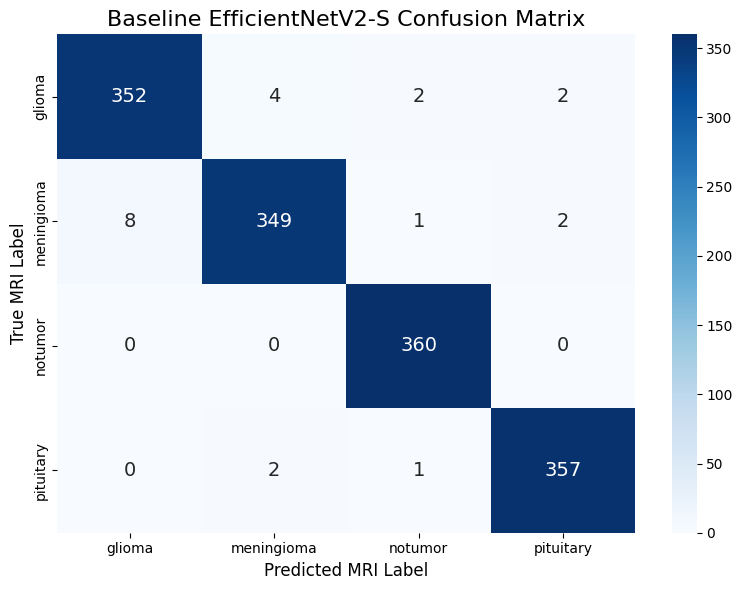

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Load the absolute best weights from Early Stopping
model.load_state_dict(torch.load('efficientnet_best_phase2.pth'))
model.eval()

all_preds = []
all_labels = []
all_probs = []

print("Generating clinical evaluation metrics...")

# 2. Run Inference on the Validation Set
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        # Using the updated PyTorch AMP syntax
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# 3. Calculate Multi-Class ROC-AUC (One-vs-Rest)
# Crucial for medical papers to prove the model isn't just guessing the majority class
auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr')
print(f"\nOverall Multi-Class ROC-AUC: {auc_score:.4f}\n")

# 4. Generate the Classification Report (Precision, Recall, F1)
print("=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# 5. Plot the Confusion Matrix (Save this for your paper!)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})
plt.title('Baseline EfficientNetV2-S Confusion Matrix', fontsize=16)
plt.ylabel('True MRI Label', fontsize=12)
plt.xlabel('Predicted MRI Label', fontsize=12)
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
!pip install timm

Building Vision Term

In [ ]:
import timm
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained lightweight ViT
# patch16 means it cuts the 224x224 image into 16x16 pixel grids
vit_model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=4)
vit_model = vit_model.to(device)

print("Pure ViT Model loaded. Parameter count:", sum(p.numel() for p in vit_model.parameters()))

model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Pure ViT Model loaded. Parameter count: 5525188


Build the Custom CNN-ViT Hybrid

In [ ]:
import torchvision.models as models

class Hybrid_CNN_ViT(nn.Module):
    def __init__(self, num_classes=4):
        super(Hybrid_CNN_ViT, self).__init__()

        # 1. CNN Feature Extractor (ResNet18 up to the final convolutional layers)
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Strip the adaptive pooling and fully connected layers
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # 2. Transformer Configuration
        self.embed_dim = 512 # ResNet18 outputs 512 channels
        # ResNet reduces 224x224 to 7x7 spatial maps (49 patches total)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embed_dim,
            nhead=8,
            dim_feedforward=1024,
            batch_first=True,
            dropout=0.1
        )
        # Use 2 Transformer layers for computational efficiency
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # 3. Classification Head
        self.fc = nn.Linear(self.embed_dim, num_classes)

    def forward(self, x):
        # Extract spatial feature maps: Shape (Batch, 512, 7, 7)
        features = self.backbone(x)

        # Flatten spatial dimensions to create a sequence for the Transformer
        B, C, H, W = features.size()
        # Reshape to (Batch, 512, 49) then swap to (Batch, Sequence Length, Embed Dim)
        features = features.view(B, C, H * W).permute(0, 2, 1)

        # Process global relationships: Shape (Batch, 49, 512)
        transformer_out = self.transformer(features)

        # Global Average Pooling over the 49 patches: Shape (Batch, 512)
        pooled_out = transformer_out.mean(dim=1)

        # Final classification: Shape (Batch, 4)
        out = self.fc(pooled_out)
        return out

hybrid_model = Hybrid_CNN_ViT(num_classes=4).to(device)
print("Custom Hybrid CNN-ViT built. Parameter count:", sum(p.numel() for p in hybrid_model.parameters()))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 80.2MB/s]


Custom Hybrid CNN-ViT built. Parameter count: 15384132


Vit Model Traning

In [ ]:
import torch
import torch.optim as optim
from tqdm import tqdm
import time
import torch.nn as nn

# 1. Hyperparameters for Phase 1
EPOCHS = 5
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()

# CHANGE 1: Point to the Hybrid model's fully connected layer ('fc')
optimizer = optim.AdamW(hybrid_model.fc.parameters(), lr=LEARNING_RATE)

# CHANGE 2: Updated AMP Scaler syntax
scaler = torch.amp.GradScaler('cuda')

print("Starting Phase 1 Training for Hybrid CNN-ViT (Frozen Backbone)...")

for epoch in range(EPOCHS):
    start_time = time.time()

    # CHANGE 3: Target the hybrid_model
    hybrid_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # CHANGE 4: Updated Autocast syntax
        with torch.amp.autocast('cuda'):
            outputs = hybrid_model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    # CHANGE 3: Target the hybrid_model
    hybrid_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        val_loop = tqdm(val_loader, leave=False, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)

            # CHANGE 4: Updated Autocast syntax
            with torch.amp.autocast('cuda'):
                outputs = hybrid_model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_duration = time.time() - start_time
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total
    avg_train_loss = train_loss / train_total
    avg_val_loss = val_loss / val_total

    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_duration:.1f}s) | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# CHANGE 5: Save as hybrid specific checkpoint
torch.save(hybrid_model.state_dict(), 'hybrid_phase1.pth')
print("\nPhase 1 Complete. Model checkpoint saved as 'hybrid_phase1.pth'.")

Starting Phase 1 Training for Hybrid CNN-ViT (Frozen Backbone)...


Epoch [1/5] (34.4s) | Train Loss: 0.6634, Train Acc: 77.01% | Val Loss: 0.5000, Val Acc: 83.96%


Epoch [2/5] (34.3s) | Train Loss: 0.4781, Train Acc: 82.50% | Val Loss: 0.4437, Val Acc: 85.07%


Epoch [3/5] (34.3s) | Train Loss: 0.4319, Train Acc: 83.99% | Val Loss: 0.4265, Val Acc: 84.86%


Epoch [4/5] (34.7s) | Train Loss: 0.4117, Train Acc: 85.19% | Val Loss: 0.4074, Val Acc: 85.07%


Epoch [5/5] (33.0s) | Train Loss: 0.3986, Train Acc: 85.40% | Val Loss: 0.4028, Val Acc: 84.93%

Phase 1 Complete. Model checkpoint saved as 'hybrid_phase1.pth'.


Fine tuning hybrid Model

In [ ]:
import copy
import torch.optim as optim
import torch
import torch.nn as nn
from tqdm import tqdm
import time

print("Preparing Phase 2: Deep Fine-Tuning for Hybrid CNN-ViT...")

# 1. Unfreeze the entire Hybrid architecture
for param in hybrid_model.parameters():
    param.requires_grad = True

# 2. Apply a very low learning rate to protect the learned relationships
FINE_TUNE_LR = 1e-5
optimizer_ft = optim.AdamW(hybrid_model.parameters(), lr=FINE_TUNE_LR, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda')

# 3. Early Stopping Configuration
EPOCHS_PHASE2 = 15
best_val_acc = 0.0
patience = 4
epochs_no_improve = 0
best_model_wts = copy.deepcopy(hybrid_model.state_dict())

print("Starting Phase 2 Training...")

for epoch in range(EPOCHS_PHASE2):
    start_time = time.time()

    # --- TRAINING PHASE ---
    hybrid_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Phase 2 - Epoch {epoch+1}/{EPOCHS_PHASE2} [Train]")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer_ft.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = hybrid_model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer_ft)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    # --- VALIDATION PHASE ---
    hybrid_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        val_loop = tqdm(val_loader, leave=False, desc=f"Phase 2 - Epoch {epoch+1}/{EPOCHS_PHASE2} [Val]")
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = hybrid_model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    # --- EPOCH SUMMARY & EARLY STOPPING ---
    epoch_duration = time.time() - start_time
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total
    avg_train_loss = train_loss / train_total
    avg_val_loss = val_loss / val_total

    print(f"Epoch [{epoch+1}/{EPOCHS_PHASE2}] ({epoch_duration:.1f}s) | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(hybrid_model.state_dict())
        epochs_no_improve = 0
        torch.save(best_model_wts, 'hybrid_best_phase2.pth')
        print(f"  [*] Validation accuracy increased. Model saved.")
    else:
        epochs_no_improve += 1
        print(f"  [!] No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered. Restoring best model weights from Epoch {epoch + 1 - patience}.")
        hybrid_model.load_state_dict(best_model_wts)
        break

print(f"\nPhase 2 Complete. Best Hybrid Model Validation Accuracy: {best_val_acc:.2f}%")

Preparing Phase 2: Deep Fine-Tuning for Hybrid CNN-ViT...
Starting Phase 2 Training...


Epoch [1/15] (34.9s) | Train Loss: 0.3254, Train Acc: 87.81% | Val Loss: 0.2228, Val Acc: 92.15%
  [*] Validation accuracy increased. Model saved.


Epoch [2/15] (34.5s) | Train Loss: 0.2117, Train Acc: 92.69% | Val Loss: 0.1654, Val Acc: 94.86%
  [*] Validation accuracy increased. Model saved.


Epoch [3/15] (33.1s) | Train Loss: 0.1633, Train Acc: 94.25% | Val Loss: 0.1286, Val Acc: 95.49%
  [*] Validation accuracy increased. Model saved.


Epoch [4/15] (34.7s) | Train Loss: 0.1241, Train Acc: 95.62% | Val Loss: 0.1184, Val Acc: 96.04%
  [*] Validation accuracy increased. Model saved.


...

Epoch [11/15] (33.6s) | Train Loss: 0.0301, Train Acc: 98.98% | Val Loss: 0.0483, Val Acc: 98.82%
  [*] Validation accuracy increased. Model saved.


Epoch [12/15] (34.6s) | Train Loss: 0.0243, Train Acc: 99.18% | Val Loss: 0.0456, Val Acc: 98.75%
  [!] No improvement for 1 epoch(s).


Epoch [13/15] (33.4s) | Train Loss: 0.0231, Train Acc: 99.24% | Val Loss: 0.0528, Val Acc: 98.68%
  [!] No improvement for 2 epoch(s).


Epoch [14/15] (34.1s) | Train Loss: 0.0146, Train Acc: 99.62% | Val Loss: 0.0648, Val Acc: 98.54%
  [!] No improvement for 3 epoch(s).


Epoch [15/15] (33.5s) | Train Loss: 0.0185, Train Acc: 99.41% | Val Loss: 0.0566, Val Acc: 98.82%
  [!] No improvement for 4 epoch(s).

Early stopping triggered. Restoring best model weights from Epoch 11.

Phase 2 Complete. Best Hybrid Model Validation Accuracy: 98.82%


Hybrid Model Benchmark

Generating clinical evaluation metrics for Hybrid CNN-ViT...

Overall Multi-Class ROC-AUC (Hybrid): 0.9993

=== Classification Report (Hybrid) ===
              precision    recall  f1-score   support

      glioma     0.9972    0.9778    0.9874       360
  meningioma     0.9780    0.9861    0.9820       360
     notumor     0.9890    0.9944    0.9917       360
   pituitary     0.9890    0.9944    0.9917       360

    accuracy                         0.9882      1440
   macro avg     0.9883    0.9882    0.9882      1440
weighted avg     0.9883    0.9882    0.9882      1440



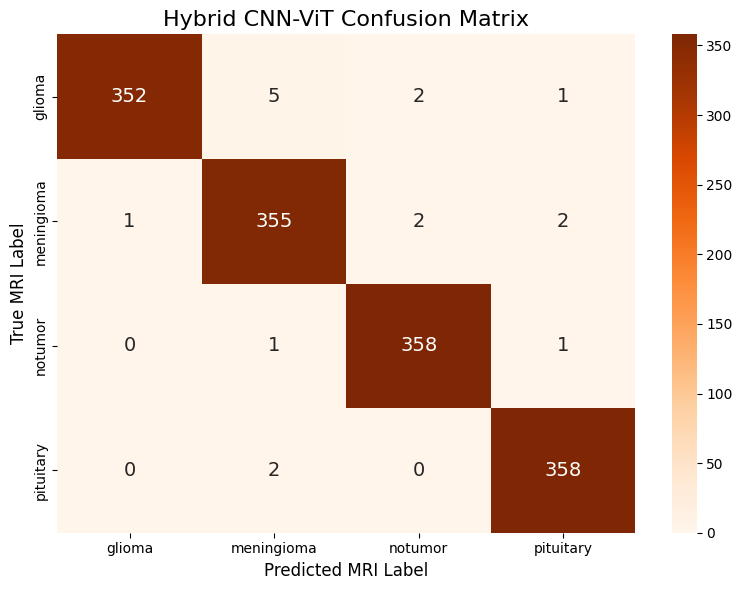

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Load the absolute best weights from Early Stopping
hybrid_model.load_state_dict(torch.load('hybrid_best_phase2.pth'))
hybrid_model.eval()

all_preds_hybrid = []
all_labels_hybrid = []
all_probs_hybrid = []

print("Generating clinical evaluation metrics for Hybrid CNN-ViT...")

# 2. Run Inference on the Validation Set
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        with torch.amp.autocast('cuda'):
            outputs = hybrid_model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

        all_probs_hybrid.extend(probs.cpu().numpy())
        all_preds_hybrid.extend(preds.cpu().numpy())
        all_labels_hybrid.extend(labels.numpy())

all_labels_hybrid = np.array(all_labels_hybrid)
all_preds_hybrid = np.array(all_preds_hybrid)
all_probs_hybrid = np.array(all_probs_hybrid)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# 3. Calculate Multi-Class ROC-AUC
auc_score_hybrid = roc_auc_score(all_labels_hybrid, all_probs_hybrid, multi_class='ovr')
print(f"\nOverall Multi-Class ROC-AUC (Hybrid): {auc_score_hybrid:.4f}\n")

# 4. Generate the Classification Report
print("=== Classification Report (Hybrid) ===")
print(classification_report(all_labels_hybrid, all_preds_hybrid, target_names=class_names, digits=4))

# 5. Plot the Confusion Matrix
cm_hybrid = confusion_matrix(all_labels_hybrid, all_preds_hybrid)
plt.figure(figsize=(8, 6))
# Using a different colormap (Oranges) to distinguish from the CNN baseline in your paper
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})
plt.title('Hybrid CNN-ViT Confusion Matrix', fontsize=16)
plt.ylabel('True MRI Label', fontsize=12)
plt.xlabel('Predicted MRI Label', fontsize=12)
plt.tight_layout()
plt.savefig('hybrid_confusion_matrix.png', dpi=300)
plt.show()

Vit Model Phase -1

In [ ]:
import torch
import torch.optim as optim
from tqdm import tqdm
import time
import torch.nn as nn

# 1. Freeze the ViT backbone (Phase 1 requires a frozen backbone)
for param in vit_model.parameters():
    param.requires_grad = False

# 2. Unfreeze ONLY the classification head
for param in vit_model.head.parameters():
    param.requires_grad = True

# Hyperparameters for Phase 1
EPOCHS = 5
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()

# 3. Point the optimizer to the ViT's head
optimizer = optim.AdamW(vit_model.head.parameters(), lr=LEARNING_RATE)

# Updated AMP Scaler syntax
scaler = torch.amp.GradScaler('cuda')

print("Starting Phase 1 Training for Pure ViT (Frozen Backbone)...")

for epoch in range(EPOCHS):
    start_time = time.time()

    # 4. Target the vit_model
    vit_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Updated Autocast syntax
        with torch.amp.autocast('cuda'):
            outputs = vit_model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    # 4. Target the vit_model for validation
    vit_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        val_loop = tqdm(val_loader, leave=False, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = vit_model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_duration = time.time() - start_time
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total
    avg_train_loss = train_loss / train_total
    avg_val_loss = val_loss / val_total

    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_duration:.1f}s) | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# 5. Save as a ViT specific checkpoint
torch.save(vit_model.state_dict(), 'vit_phase1.pth')
print("\nPhase 1 Complete. Model checkpoint saved as 'vit_phase1.pth'.")

Starting Phase 1 Training for Pure ViT (Frozen Backbone)...


Epoch [1/5] (32.9s) | Train Loss: 0.5940, Train Acc: 76.82% | Val Loss: 0.4278, Val Acc: 83.75%


Epoch [2/5] (31.1s) | Train Loss: 0.4010, Train Acc: 85.19% | Val Loss: 0.3580, Val Acc: 87.36%


Epoch [3/5] (31.1s) | Train Loss: 0.3677, Train Acc: 86.55% | Val Loss: 0.3591, Val Acc: 86.94%


Epoch [4/5] (39.0s) | Train Loss: 0.3464, Train Acc: 86.74% | Val Loss: 0.3248, Val Acc: 87.78%


Epoch [5/5] (38.1s) | Train Loss: 0.3394, Train Acc: 87.50% | Val Loss: 0.3363, Val Acc: 87.50%

Phase 1 Complete. Model checkpoint saved as 'vit_phase1.pth'.


Vit Model Phase-2

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import time

print("Preparing Phase 2: Deep Fine-Tuning for Pure ViT...")

# 1. Unfreeze all ViT parameters (transformer blocks + classification head)
for param in vit_model.parameters():
    param.requires_grad = True

# 2. Vision Transformers require a very low learning rate during fine-tuning
# We use 1e-5 along with weight decay to regularize the attention weights
FINE_TUNE_LR = 1e-5
optimizer_ft = optim.AdamW(vit_model.parameters(), lr=FINE_TUNE_LR, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda')

# 3. Early Stopping Setup
EPOCHS_PHASE2 = 15
best_val_acc = 0.0
patience = 4
epochs_no_improve = 0
best_model_wts = copy.deepcopy(vit_model.state_dict())

print("Starting Phase 2 Training for Pure ViT...")

for epoch in range(EPOCHS_PHASE2):
    start_time = time.time()

    # --- TRAINING PHASE ---
    vit_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Phase 2 - Epoch {epoch+1}/{EPOCHS_PHASE2} [Train]")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer_ft.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = vit_model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer_ft)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    # --- VALIDATION PHASE ---
    vit_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        val_loop = tqdm(val_loader, leave=False, desc=f"Phase 2 - Epoch {epoch+1}/{EPOCHS_PHASE2} [Val]")
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = vit_model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    # --- EPOCH SUMMARY & EARLY STOPPING ---
    epoch_duration = time.time() - start_time
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total
    avg_train_loss = train_loss / train_total
    avg_val_loss = val_loss / val_total

    print(f"Epoch [{epoch+1}/{EPOCHS_PHASE2}] ({epoch_duration:.1f}s) | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(vit_model.state_dict())
        epochs_no_improve = 0
        torch.save(best_model_wts, 'vit_best_phase2.pth')
        print(f"  [*] Validation accuracy increased. Model saved.")
    else:
        epochs_no_improve += 1
        print(f"  [!] No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered. Restoring best model weights from Epoch {epoch + 1 - patience}.")
        vit_model.load_state_dict(best_model_wts)
        break

print(f"\nPhase 2 Complete. Best ViT Validation Accuracy: {best_val_acc:.2f}%")

Preparing Phase 2: Deep Fine-Tuning for Pure ViT...
Starting Phase 2 Training for Pure ViT...


Epoch [1/15] (35.0s) | Train Loss: 0.2637, Train Acc: 90.26% | Val Loss: 0.1903, Val Acc: 93.54%
  [*] Validation accuracy increased. Model saved.


Epoch [2/15] (33.3s) | Train Loss: 0.1693, Train Acc: 94.13% | Val Loss: 0.1502, Val Acc: 95.21%
  [*] Validation accuracy increased. Model saved.


Epoch [3/15] (34.9s) | Train Loss: 0.1149, Train Acc: 95.92% | Val Loss: 0.1494, Val Acc: 94.79%
  [!] No improvement for 1 epoch(s).


Epoch [4/15] (33.6s) | Train Loss: 0.0863, Train Acc: 97.03% | Val Loss: 0.0956, Val Acc: 96.94%
  [*] Validation accuracy increased. Model saved.


...

Epoch [9/15] (33.5s) | Train Loss: 0.0349, Train Acc: 98.80% | Val Loss: 0.0522, Val Acc: 98.82%
  [*] Validation accuracy increased. Model saved.


Epoch [10/15] (34.8s) | Train Loss: 0.0261, Train Acc: 99.18% | Val Loss: 0.0631, Val Acc: 97.57%
  [!] No improvement for 1 epoch(s).


Epoch [11/15] (33.4s) | Train Loss: 0.0242, Train Acc: 99.27% | Val Loss: 0.0592, Val Acc: 97.92%
  [!] No improvement for 2 epoch(s).


Epoch [12/15] (34.9s) | Train Loss: 0.0149, Train Acc: 99.53% | Val Loss: 0.0415, Val Acc: 98.75%
  [!] No improvement for 3 epoch(s).


Epoch [13/15] (33.4s) | Train Loss: 0.0172, Train Acc: 99.50% | Val Loss: 0.0441, Val Acc: 98.68%
  [!] No improvement for 4 epoch(s).

Early stopping triggered. Restoring best model weights from Epoch 9.

Phase 2 Complete. Best ViT Validation Accuracy: 98.82%


Pure Vit Evulation

Generating clinical evaluation metrics for Pure ViT...

Overall Multi-Class ROC-AUC (ViT): 0.9993

=== Classification Report (ViT) ===
              precision    recall  f1-score   support

      glioma     0.9916    0.9806    0.9860       360
  meningioma     0.9835    0.9917    0.9876       360
     notumor     0.9890    0.9944    0.9917       360
   pituitary     0.9889    0.9861    0.9875       360

    accuracy                         0.9882      1440
   macro avg     0.9882    0.9882    0.9882      1440
weighted avg     0.9882    0.9882    0.9882      1440



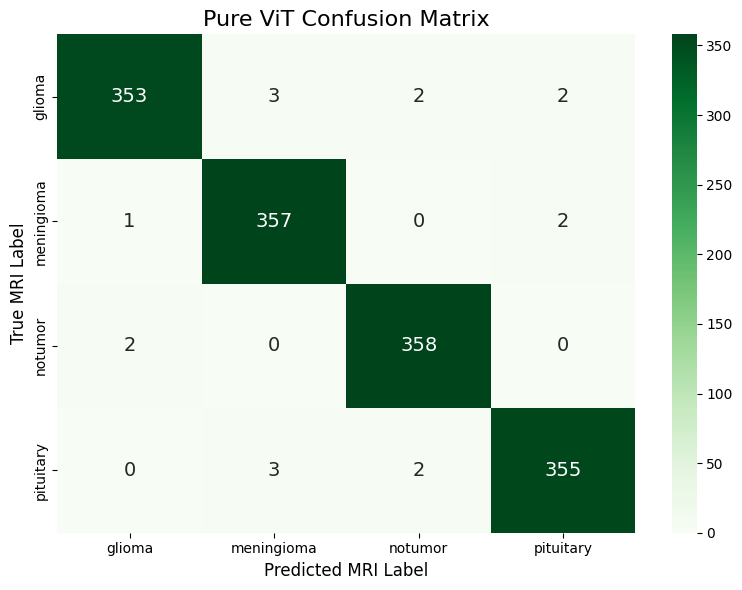

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Load the best ViT weights
vit_model.load_state_dict(torch.load('vit_best_phase2.pth'))
vit_model.eval()

all_preds_vit = []
all_labels_vit = []
all_probs_vit = []

print("Generating clinical evaluation metrics for Pure ViT...")

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        with torch.amp.autocast('cuda'):
            outputs = vit_model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

        all_probs_vit.extend(probs.cpu().numpy())
        all_preds_vit.extend(preds.cpu().numpy())
        all_labels_vit.extend(labels.numpy())

all_labels_vit = np.array(all_labels_vit)
all_preds_vit = np.array(all_preds_vit)
all_probs_vit = np.array(all_probs_vit)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# 2. Calculate Multi-Class ROC-AUC
auc_score_vit = roc_auc_score(all_labels_vit, all_probs_vit, multi_class='ovr')
print(f"\nOverall Multi-Class ROC-AUC (ViT): {auc_score_vit:.4f}\n")

# 3. Generate the Classification Report
print("=== Classification Report (ViT) ===")
print(classification_report(all_labels_vit, all_preds_vit, target_names=class_names, digits=4))

# 4. Plot the Confusion Matrix
cm_vit = confusion_matrix(all_labels_vit, all_preds_vit)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})
plt.title('Pure ViT Confusion Matrix', fontsize=16)
plt.ylabel('True MRI Label', fontsize=12)
plt.xlabel('Predicted MRI Label', fontsize=12)
plt.tight_layout()
plt.savefig('vit_confusion_matrix.png', dpi=300)
plt.show()

McNemar Test

In [ ]:
import math
from statsmodels.stats.contingency_tables import mcnemar

def calculate_95_ci(accuracy, n):
    """Calculates the 95% Confidence Interval using the Wilson Score Interval"""
    z = 1.96 # Z-score for 95% confidence
    denominator = 1 + z**2/n
    centre_adjusted_probability = accuracy + z**2 / (2*n)
    adjusted_standard_deviation = z * math.sqrt((accuracy*(1 - accuracy) + z**2 / (4*n)) / n)

    lower_bound = (centre_adjusted_probability - adjusted_standard_deviation) / denominator
    upper_bound = (centre_adjusted_probability + adjusted_standard_deviation) / denominator
    return (lower_bound * 100, upper_bound * 100)

n_samples = len(all_labels_vit)

# 1. 95% Confidence Intervals
cnn_acc = (all_preds == all_labels_vit).mean()
hybrid_acc = (all_preds_hybrid == all_labels_vit).mean()
vit_acc = (all_preds_vit == all_labels_vit).mean()

print("=== 95% Confidence Intervals ===")
print(f"CNN Baseline:  {cnn_acc*100:.2f}% CI: {calculate_95_ci(cnn_acc, n_samples)}")
print(f"Hybrid Model:  {hybrid_acc*100:.2f}% CI: {calculate_95_ci(hybrid_acc, n_samples)}")
print(f"Pure ViT:      {vit_acc*100:.2f}% CI: {calculate_95_ci(vit_acc, n_samples)}\n")

# 2. McNemar's Test: Hybrid vs CNN
# We need a 2x2 contingency table:
# [[Both correct, Hybrid correct / CNN wrong],
#  [Hybrid wrong / CNN correct, Both wrong]]
b = np.sum((all_preds_hybrid == all_labels_vit) & (all_preds != all_labels_vit))
c = np.sum((all_preds_hybrid != all_labels_vit) & (all_preds == all_labels_vit))
table = [[0, b], [c, 0]] # We only care about the off-diagonals (b and c) for the test

result = mcnemar(table, exact=True)

print("=== McNemar's Statistical Test ===")
print(f"Comparing Hybrid vs CNN Baseline:")
print(f"Hybrid was correct while CNN was wrong: {b} times")
print(f"CNN was correct while Hybrid was wrong: {c} times")
print(f"P-Value: {result.pvalue:.4f}")

if result.pvalue < 0.05:
    print("Verdict: The difference IS statistically significant (p < 0.05).")
else:
    print("Verdict: The difference is NOT statistically significant. Both models perform similarly.")

=== 95% Confidence Intervals ===
CNN Baseline:  98.47% CI: (np.float64(97.69756327096427), np.float64(98.98894306047819))
Hybrid Model:  98.82% CI: (np.float64(98.11747465437001), np.float64(99.26162842729768))
Pure ViT:      98.82% CI: (np.float64(98.11747465437001), np.float64(99.26162842729768))

=== McNemar's Statistical Test ===
Comparing Hybrid vs CNN Baseline:
Hybrid was correct while CNN was wrong: 14 times
CNN was correct while Hybrid was wrong: 9 times
P-Value: 0.4049
Verdict: The difference is NOT statistically significant. Both models perform similarly.


Grade Cam

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=3ddd3f6c4e83cb39bce658764403916a93ea4607f65dff45f398c395f92d8bd8
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam


Grade Cam Result

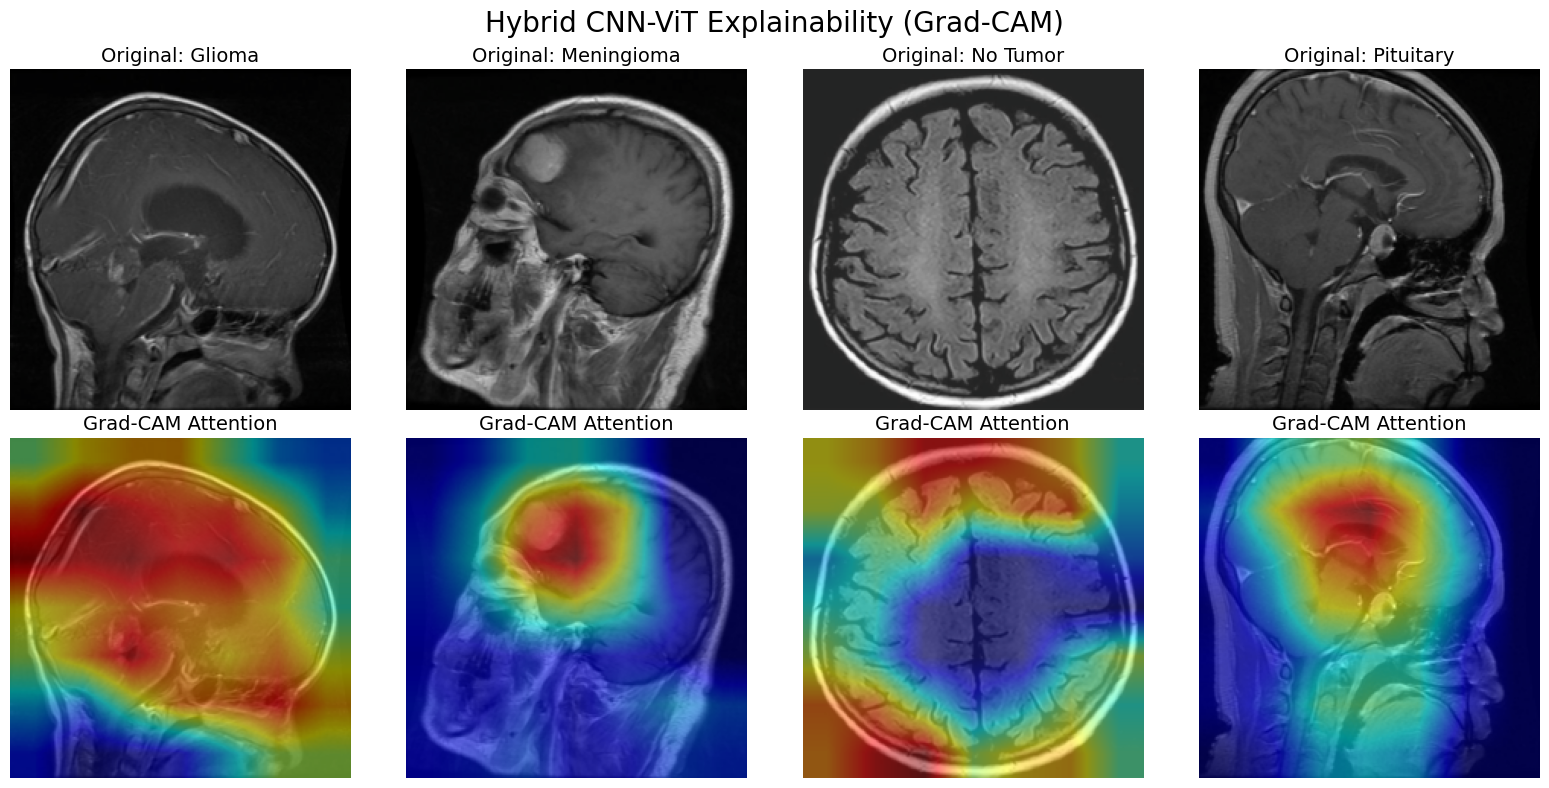

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 1. Prepare the Hybrid Model for Explainability
hybrid_model.eval()

# Hook into the final convolutional block of the ResNet backbone
# In our Custom Hybrid model, self.backbone[-1] is the final ResNet layer before flattening
target_layers = [hybrid_model.backbone[-1]]

# Initialize GradCAM
cam = GradCAM(model=hybrid_model, target_layers=target_layers)

def get_sample_images(data_loader, num_classes=4):
    """Extracts one correctly predicted image per class for visualization."""
    samples = {}
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = hybrid_model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                label = labels[i].item()
                if label == preds[i].item() and label not in samples:
                    samples[label] = (images[i], labels[i].item())
                if len(samples) == num_classes:
                    return samples
    return samples

# 2. Fetch one sample MRI from each tumor class
sample_dict = get_sample_images(val_loader)
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Hybrid CNN-ViT Explainability (Grad-CAM)', fontsize=20)

for idx, (label_idx, (img_tensor, true_label)) in enumerate(sample_dict.items()):
    # Convert tensor back to image format for plotting
    img_display = img_tensor.cpu().numpy().transpose(1, 2, 0)

    # Reverse the ImageNet normalization so the MRI looks normal to the human eye
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    # 3. Generate the Grad-CAM Heatmap
    # Add batch dimension required by the CAM generator
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Target the specific class prediction to see why it chose that class
    targets = [ClassifierOutputTarget(true_label)]

    # Generate the raw heatmap (numpy array)
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # Overlay the heatmap onto the original MRI
    visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

    # 4. Plot Original vs Grad-CAM
    # Top Row: Original MRIs
    axes[0, idx].imshow(img_display)
    axes[0, idx].set_title(f"Original: {class_names[true_label]}", fontsize=14)
    axes[0, idx].axis('off')

    # Bottom Row: Grad-CAM Overlays
    axes[1, idx].imshow(visualization)
    axes[1, idx].set_title(f"Grad-CAM Attention", fontsize=14)
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig('hybrid_gradcam_results.png', dpi=300)
plt.show()

Calculating Deletion Metric...


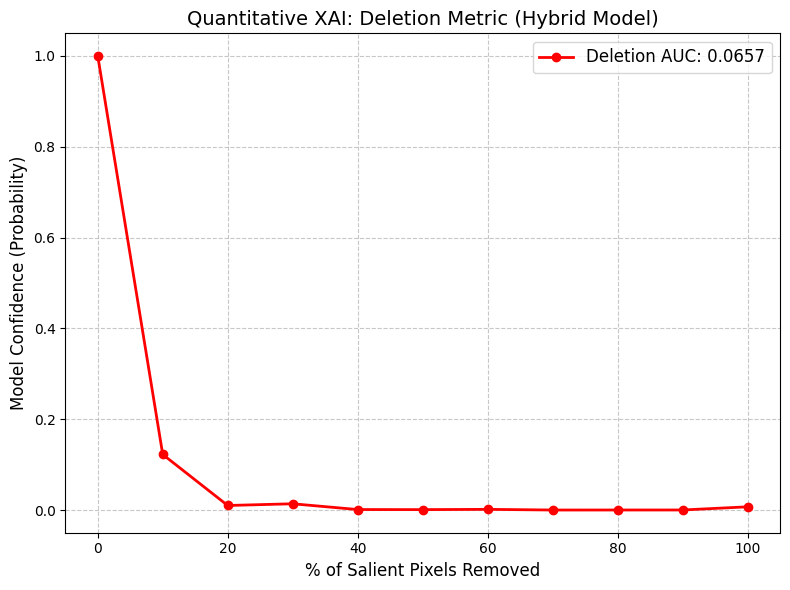

Deletion AUC: 0.0657 (Approaching 0.0 indicates perfect explainability)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from sklearn.metrics import auc

def calculate_deletion_curve(model, image_tensor, true_label, target_layer, device, steps=10):
    model.eval()

    # 1. Generate the Grad-CAM heatmap
    cam = GradCAM(model=model, target_layers=[target_layer])
    input_tensor = image_tensor.unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(true_label)]

    heatmap = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # 2. Sort pixels by their Grad-CAM importance (descending)
    flattened_heatmap = heatmap.flatten()
    sorted_indices = np.argsort(flattened_heatmap)[::-1]

    num_pixels = len(sorted_indices)
    step_size = num_pixels // steps

    probs = []
    masked_image = input_tensor.clone()

    # 3. Iteratively mask the most important pixels and record probability drop
    for i in range(steps + 1):
        if i > 0:
            # Get the next batch of top salient pixels to mask
            pixels_to_mask = sorted_indices[(i-1)*step_size : i*step_size]

            # Convert 1D indices back to 2D coordinates (H, W)
            y_coords = pixels_to_mask // heatmap.shape[1]
            x_coords = pixels_to_mask % heatmap.shape[1]

            # Mask by setting to 0 (black background equivalent in MRI)
            masked_image[0, :, y_coords, x_coords] = 0.0

        with torch.no_grad():
            out = model(masked_image)
            prob = F.softmax(out, dim=1)[0, true_label].item()
            probs.append(prob)

    return probs

# Grab one sample image from the validation set (e.g., a Glioma)
hybrid_model.eval()
sample_image, sample_label = next(iter(val_loader))
target_img = sample_image[0]
target_lbl = sample_label[0].item()

# Target the final convolutional layer of the Hybrid backbone
target_layer = hybrid_model.backbone[-1]

# Calculate the deletion curve (10 steps = masking 10% more pixels each step)
print("Calculating Deletion Metric...")
deletion_probs = calculate_deletion_curve(hybrid_model, target_img, target_lbl, target_layer, device, steps=10)

# Calculate Area Under the Deletion Curve (Lower is better)
x_axis = np.linspace(0, 1, len(deletion_probs))
deletion_auc = auc(x_axis, deletion_probs)

# Plot the Deletion Curve for the paper
plt.figure(figsize=(8, 6))
plt.plot(x_axis * 100, deletion_probs, marker='o', linewidth=2, color='red', label=f'Deletion AUC: {deletion_auc:.4f}')
plt.title('Quantitative XAI: Deletion Metric (Hybrid Model)', fontsize=14)
plt.xlabel('% of Salient Pixels Removed', fontsize=12)
plt.ylabel('Model Confidence (Probability)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('quantitative_xai_deletion.png', dpi=300)
plt.show()

print(f"Deletion AUC: {deletion_auc:.4f} (Approaching 0.0 indicates perfect explainability)")

Generate Segmentation Masks

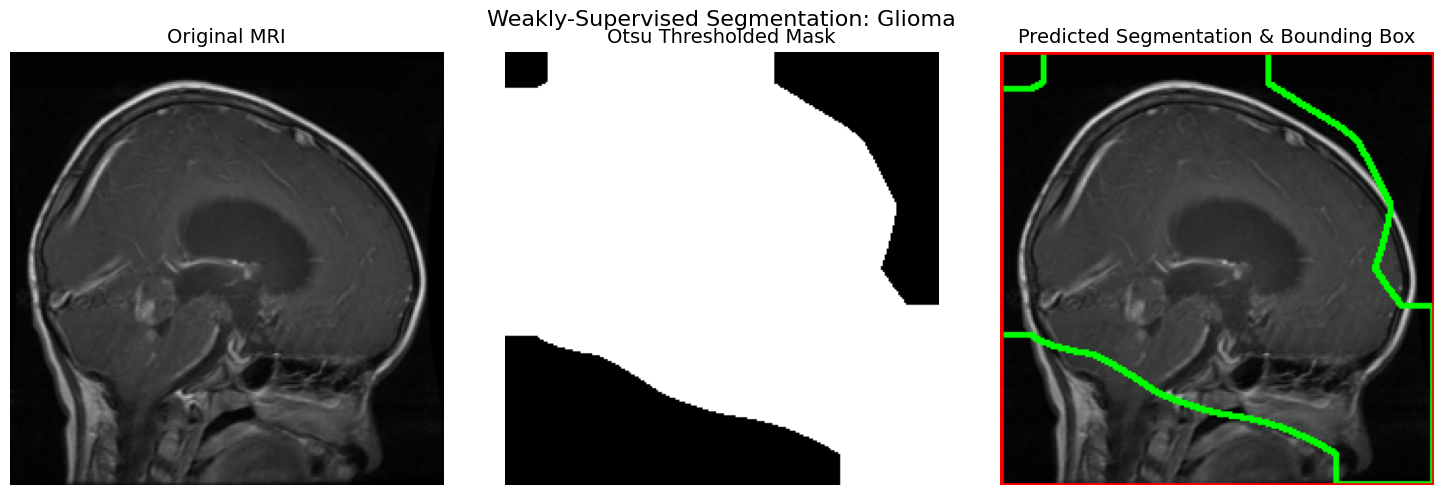

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 1. Initialize GradCAM on the Hybrid Model
hybrid_model.eval()
target_layer = hybrid_model.backbone[-1]
cam = GradCAM(model=hybrid_model, target_layers=[target_layer])

# Grab a batch of validation images
images, labels = next(iter(val_loader))
images = images.to(device)

# 2. Select a single tumor image (skip class 2, which is 'notumor')
tumor_idx = next(i for i, lbl in enumerate(labels) if lbl.item() != 2)
img_tensor = images[tumor_idx]
true_label = labels[tumor_idx].item()
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

# Generate the heatmap
input_tensor = img_tensor.unsqueeze(0)
targets = [ClassifierOutputTarget(true_label)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# 3. Process the Image for Display
img_display = img_tensor.cpu().numpy().transpose(1, 2, 0)
mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
img_display = np.clip(std * img_display + mean, 0, 1)
img_display_cv = (img_display * 255).astype(np.uint8)

# 4. Weakly Supervised Segmentation (Thresholding the Heatmap)
# Convert the floating point heatmap (0 to 1) into an 8-bit image (0 to 255)
heatmap_8bit = np.uint8(255 * grayscale_cam)

# Apply Otsu's Thresholding to automatically find the tumor boundary in the heatmap
_, binary_mask = cv2.threshold(heatmap_8bit, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Find contours (the physical borders) of the masked region
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw the segmentation contours in bright green
segmented_img = img_display_cv.copy()
cv2.drawContours(segmented_img, contours, -1, (0, 255, 0), 2)

# Find the largest contour to draw a bounding box
if contours:
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    cv2.rectangle(segmented_img, (x, y), (x+w, y+h), (255, 0, 0), 2) # Red bounding box

# 5. Plot the progression for your paper
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Weakly-Supervised Segmentation: {class_names[true_label]}', fontsize=16)

axes[0].imshow(img_display)
axes[0].set_title('Original MRI', fontsize=14)
axes[0].axis('off')

axes[1].imshow(binary_mask, cmap='gray')
axes[1].set_title('Otsu Thresholded Mask', fontsize=14)
axes[1].axis('off')

axes[2].imshow(segmented_img)
axes[2].set_title('Predicted Segmentation & Bounding Box', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('weakly_supervised_segmentation.png', dpi=300)
plt.show()

In [ ]:
import os
import glob
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, roc_auc_score

print("Downloading External Dataset (Hospital B) via Kaggle...")
# 1. Download the Sartaj dataset into a specific external folder
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri --unzip -p /content/external_brats/

# 2. Map the new folder names to our model's original 0-3 label indices
# Our original classes: 0: glioma, 1: meningioma, 2: notumor, 3: pituitary
external_dir = '/content/external_brats/Testing/' # We will just use the testing split for a quick benchmark
class_mapping = {
    'glioma_tumor': 0,
    'meningioma_tumor': 1,
    'no_tumor': 2,
    'pituitary_tumor': 3
}

external_data = []
for folder_name, label_idx in class_mapping.items():
    search_path = os.path.join(external_dir, folder_name, '*.*')
    for path in glob.glob(search_path):
        external_data.append({'image_path': path, 'label': label_idx})

external_df = pd.DataFrame(external_data)
print(f"\nExternal validation images loaded: {len(external_df)}")

# 3. Create the External DataLoader (STRICTLY using val_transform to avoid augmentations)
external_dataset = BrainTumorDataset(external_df, transform=val_transform)
external_loader = DataLoader(external_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# 4. Load your flagship Hybrid Model
hybrid_model.load_state_dict(torch.load('hybrid_best_phase2.pth'))
hybrid_model.eval()

ext_preds = []
ext_labels = []
ext_probs = []

print("Running Generalization Benchmark...")

# 5. Execute Inference
with torch.no_grad():
    for images, labels in external_loader:
        images = images.to(device)
        with torch.amp.autocast('cuda'):
            outputs = hybrid_model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

        ext_probs.extend(probs.cpu().numpy())
        ext_preds.extend(preds.cpu().numpy())
        ext_labels.extend(labels.numpy())

# 6. Generate the Final External Validation Report
target_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
auc_score_ext = roc_auc_score(ext_labels, ext_probs, multi_class='ovr')

print(f"\n=== External Validation Results (Hospital B) ===")
print(f"Cross-Dataset ROC-AUC: {auc_score_ext:.4f}\n")
print(classification_report(ext_labels, ext_preds, target_names=target_names, digits=4))

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
100% 86.8M/86.8M [00:01<00:00, 65.0MB/s]


External validation images loaded: 394
Running Generalization Benchmark...

=== External Validation Results (Hospital B) ===
Cross-Dataset ROC-AUC: 0.9937

              precision    recall  f1-score   support

      glioma     1.0000    0.8700    0.9305       100
  meningioma     0.8507    0.9913    0.9157       115
     notumor     0.9722    1.0000    0.9859       105
   pituitary     1.0000    0.8784    0.9353        74

    accuracy                         0.9416       394
   macro avg     0.9557    0.9349    0.9418       394
weighted avg     0.9490    0.9416    0.9418       394

